In [1]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, QuantileTransformer
from sklearn.metrics import accuracy_score
from tscglue.models import NoScaler, SparseScaler
import numpy as np
from sklearn.linear_model import RidgeClassifierCV
from aeon.classification import BaseClassifier
from aeon.transformations.collection.convolution_based import MultiRocket
from aeon.transformations.collection.convolution_based._hydra import HydraTransformer
from aeon.utils.validation import check_n_jobs
from aeon.datasets.tsc_datasets import univariate
from pathlib import Path
import polars as pl
from tscglue import utils

In [2]:
class MultiRocketHydraBenchmarkClassifier(BaseClassifier):
    _tags = {
        "capability:multivariate": True,
        "capability:multithreading": True,
        "algorithm_type": "convolution",
        "python_dependencies": "torch",
    }

    def __init__(
        self,
        scaler_list=None, # dictionary of type {"MR": ["standard", "robust", ...], "HY": ["minmax", "none", ...]}
        class_weight=None,
        n_jobs: int = -1,
        random_state=None,
    ):
        if scaler_list is None:
            scaler_list = {"HY": ["sparse"], "MR": ["standard"]}
        self.scaler_list = scaler_list
        self.class_weight = class_weight
        self.n_jobs = n_jobs
        self.random_state = random_state

        super().__init__()

    def _fit(self, X, y):
        self._n_jobs = check_n_jobs(self.n_jobs)
        # extract features
        self._transform_hydra = HydraTransformer(
            n_jobs=self._n_jobs,
            random_state=self.random_state,
        )
        Xt_hydra = self._transform_hydra.fit_transform(X).numpy()
        # scale features
        self.MR_scalers, self.HY_scalers = self.get_scalers()

        HY_features = []
        for scaler in self.HY_scalers:
            self._scale_hydra = scaler
            Xt_hydra_scale = self._scale_hydra.fit_transform(Xt_hydra)
            HY_features.append(Xt_hydra_scale)

        HY_features = np.concatenate(HY_features, axis=1)

        #extract MR features
        self._transform_multirocket = MultiRocket(
            n_jobs=self._n_jobs,
            random_state=self.random_state,
        )
        Xt_multirocket = self._transform_multirocket.fit_transform(X)

        #scale MR features
        MR_features = []
        for scaler in self.MR_scalers:
            self._scale_multirocket = scaler
            Xt_multirocket_scale = self._scale_multirocket.fit_transform(Xt_multirocket)
            MR_features.append(Xt_multirocket_scale)
        MR_features = np.concatenate(MR_features, axis=1)

        Xt = np.concatenate((HY_features, MR_features), axis=1)

        self.classifier = RidgeClassifierCV(
            alphas=np.logspace(-3, 3, 10), class_weight=self.class_weight
        )
        self.classifier.fit(Xt, y)

        return self

    def _predict(self, X) -> np.ndarray:
        Xt_hydra = self._transform_hydra.transform(X).numpy()
        HY_scaled = [scaler.transform(Xt_hydra) for scaler in self.HY_scalers]
        HY_scaled = np.concatenate(HY_scaled, axis=1)

        Xt_multirocket = self._transform_multirocket.transform(X)
        MR_scaled = [scaler.transform(Xt_multirocket) for scaler in self.MR_scalers]
        MR_scaled = np.concatenate(MR_scaled, axis=1)

        Xt = np.concatenate((HY_scaled, MR_scaled), axis=1)

        return self.classifier.predict(Xt)

    def _get_scalar(self, name):
        factory = {
            "sparse": SparseScaler(),
            "standard": StandardScaler(),
            "robust": RobustScaler(),
            "minmax": MinMaxScaler(),
            "none": NoScaler(),
            "quantile": QuantileTransformer(output_distribution="normal"),
        }
        return factory[name]

    def get_scalers(self):
        # factory = {
        #     "sparse": SparseScaler,
        #     "standard": StandardScaler,
        #     "robust": RobustScaler,
        #     "minmax": MinMaxScaler,
        #     "none": NoScaler,
        #     "quantile": QuantileTransformer,
        # }

        #def build_list(names):
        #    return [factory[name]() for name in names]

        #HY_scalers = build_list(self.scaler_list["HY"])
        #MR_scalers = build_list(self.scaler_list["MR"])

        HY_scalers = [self._get_scalar(s) for s in self.scaler_list["HY"]]
        MR_scalers = [self._get_scalar(s) for s in self.scaler_list["MR"]]

        return MR_scalers, HY_scalers

In [3]:
print(len(univariate))

128


#### Cache

In [4]:
class LocalFileCache:
    def __init__(self, base_dir: str):
        self.base_dir = Path(base_dir)
        self.base_dir.mkdir(parents=True, exist_ok=True)

    def exists(self, filename: str) -> bool:
        return (self.base_dir / filename).exists()

    def add(self, df: pl.DataFrame, filename: str):
        df.write_parquet(self.base_dir / filename)

### Test default scalers

In [5]:
from tscglue import utils

X_train, y_train, X_test, y_test = utils.load_dataset("ArrowHead")
clf = MultiRocketHydraBenchmarkClassifier(random_state=0)
clf.fit(X_train, y_train)
preds = clf.predict(X_test)
acc = accuracy_score(y_test, preds)
print(acc)

0.8628571428571429


### Calculate all combinations

In [6]:
scaler_names = ["sparse", "standard", "robust", "minmax", "none", "quantile"]
combos = []
cache = LocalFileCache("scaler-combinations")
for dataset in univariate:
    for hy in scaler_names:
        for mr in scaler_names:
            combos.append((dataset, hy, mr, f"MR-{mr}-HY-{hy}"))
n = len(combos)
for i, (dataset, hy, mr, name) in enumerate(combos, 1):
    try:
        stats = {
            "dataset": dataset,
            "model": name,
        }
        hash_val = pl.DataFrame([stats]).hash_rows(seed=42, seed_1=1, seed_2=2, seed_3=3).item()
        file_name = f"{hash_val}.parquet"
        if cache.exists(file_name):
            print(f"[{i}/{n}] Skipping: Dataset={dataset}, Scaler combination={name}")
            continue
        else:
            print(f"[{i}/{n}] Processing: Dataset={dataset}, Scaler combination={name}")
        clf = MultiRocketHydraBenchmarkClassifier(random_state=0, scaler_list={"MR": [mr], "HY": [hy]})
        X_train, y_train, X_test, y_test = utils.load_dataset(dataset)
        clf.fit(X_train, y_train)
        preds = clf.predict(X_test)
        acc = accuracy_score(y_test, preds)
        stats["test_accuracy"] = acc
        df_stat = pl.DataFrame([stats])
        cache.add(df_stat, file_name)
    except Exception as e:
        print(f"Error processing Dataset={dataset}, Model={name}: {e}")

[1/4608] Skipping: Dataset=ACSF1, Scaler combination=MR-sparse-HY-sparse
[2/4608] Skipping: Dataset=ACSF1, Scaler combination=MR-standard-HY-sparse
[3/4608] Skipping: Dataset=ACSF1, Scaler combination=MR-robust-HY-sparse
[4/4608] Skipping: Dataset=ACSF1, Scaler combination=MR-minmax-HY-sparse
[5/4608] Skipping: Dataset=ACSF1, Scaler combination=MR-none-HY-sparse
[6/4608] Skipping: Dataset=ACSF1, Scaler combination=MR-quantile-HY-sparse
[7/4608] Skipping: Dataset=ACSF1, Scaler combination=MR-sparse-HY-standard
[8/4608] Skipping: Dataset=ACSF1, Scaler combination=MR-standard-HY-standard
[9/4608] Skipping: Dataset=ACSF1, Scaler combination=MR-robust-HY-standard
[10/4608] Skipping: Dataset=ACSF1, Scaler combination=MR-minmax-HY-standard
[11/4608] Skipping: Dataset=ACSF1, Scaler combination=MR-none-HY-standard
[12/4608] Skipping: Dataset=ACSF1, Scaler combination=MR-quantile-HY-standard
[13/4608] Skipping: Dataset=ACSF1, Scaler combination=MR-sparse-HY-robust
[14/4608] Skipping: Dataset=ACS

In [8]:
print(combos)

[('ACSF1', 'sparse', 'sparse', 'MR-sparse-HY-sparse'), ('ACSF1', 'sparse', 'standard', 'MR-standard-HY-sparse'), ('ACSF1', 'sparse', 'robust', 'MR-robust-HY-sparse'), ('ACSF1', 'sparse', 'minmax', 'MR-minmax-HY-sparse'), ('ACSF1', 'sparse', 'none', 'MR-none-HY-sparse'), ('ACSF1', 'sparse', 'quantile', 'MR-quantile-HY-sparse'), ('ACSF1', 'standard', 'sparse', 'MR-sparse-HY-standard'), ('ACSF1', 'standard', 'standard', 'MR-standard-HY-standard'), ('ACSF1', 'standard', 'robust', 'MR-robust-HY-standard'), ('ACSF1', 'standard', 'minmax', 'MR-minmax-HY-standard'), ('ACSF1', 'standard', 'none', 'MR-none-HY-standard'), ('ACSF1', 'standard', 'quantile', 'MR-quantile-HY-standard'), ('ACSF1', 'robust', 'sparse', 'MR-sparse-HY-robust'), ('ACSF1', 'robust', 'standard', 'MR-standard-HY-robust'), ('ACSF1', 'robust', 'robust', 'MR-robust-HY-robust'), ('ACSF1', 'robust', 'minmax', 'MR-minmax-HY-robust'), ('ACSF1', 'robust', 'none', 'MR-none-HY-robust'), ('ACSF1', 'robust', 'quantile', 'MR-quantile-HY-r

In [7]:
import polars as pl
from pathlib import Path

def load_all_results(cache_dir="scaler-combinations"):
    path = Path(cache_dir)
    files = list(path.glob("*.parquet"))

    if not files:
        return pl.DataFrame()

    dfs = [pl.read_parquet(f) for f in files]
    return pl.concat(dfs, how="vertical")

df = load_all_results()
df = df.filter(pl.col("dataset") != "ArrowHead")
df_matrix = df.pivot(
    index="dataset",
    columns="model",
    values="test_accuracy"
)
scalers_used = df_matrix.columns[1:]   # exclude "dataset"
accs = df_matrix.select(scalers_used).to_numpy().tolist()

/tmp/ipykernel_542668/1311764823.py:16: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  df_matrix = df.pivot(


(<Figure size 600x550 with 1 Axes>, <Axes: >)

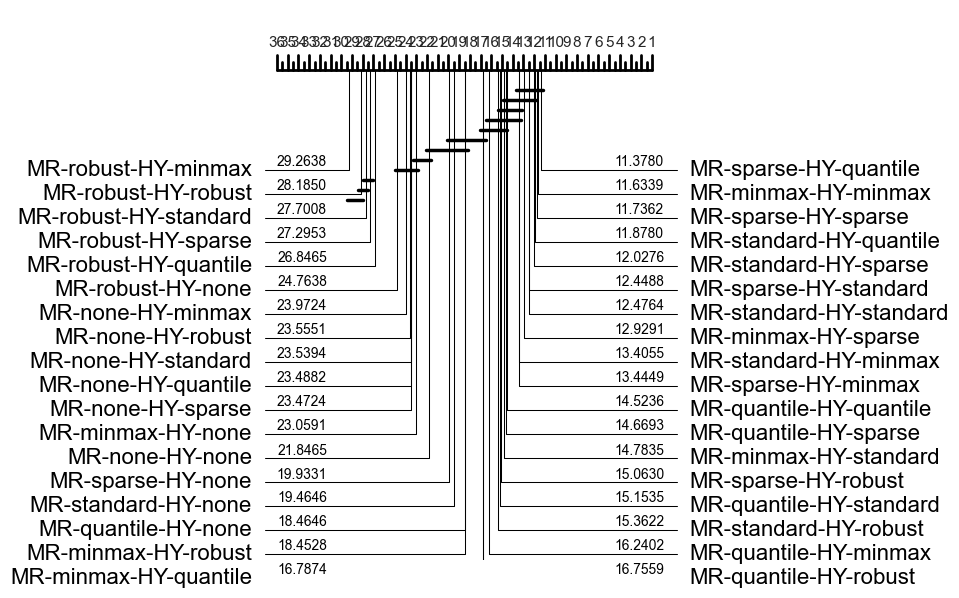

In [8]:
from aeon.visualisation import plot_critical_difference

plot_critical_difference(accs, scalers_used)